In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [3]:
# Load dataset
d = sns.load_dataset('iris')


In [4]:
d.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
d.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
# Features and target
X = d.drop('species', axis=1)
y = d['species']

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)
     

In [9]:
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=0.2, random_state=42,stratify=y_int)



In [11]:
# Standardization (important for both models, especially ANN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# 1. Perceptron Model
perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X_train, y_train)

y_pred_p = perceptron.predict(X_test)
acc_p = accuracy_score(y_test, y_pred_p)

In [13]:
# Results
print("Perceptron Accuracy:", acc_p)


Perceptron Accuracy: 0.8666666666666667


In [14]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [15]:
y_train_cat = to_categorical(y_train,num_classes = 3)
y_test_cat = to_categorical(y_test,num_classes = 3)


In [16]:
ann_model = Sequential([
    Dense(16,input_dim = 4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])
     

In [17]:
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [18]:
history = ann_model.fit(X_train,y_train_cat,
                    epochs = 100,batch_size= 8, validation_split = 0.2,verbose = 1)
     

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.1667 - loss: 1.0946 - val_accuracy: 0.3333 - val_loss: 1.0417
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3958 - loss: 1.0230 - val_accuracy: 0.5833 - val_loss: 0.9711
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5208 - loss: 0.9519 - val_accuracy: 0.5417 - val_loss: 0.9122
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5938 - loss: 0.8921 - val_accuracy: 0.6667 - val_loss: 0.8573
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6875 - loss: 0.8401 - val_accuracy: 0.7917 - val_loss: 0.8071
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7604 - loss: 0.7903 - val_accuracy: 0.7917 - val_loss: 0.7629
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7917 - loss: 0.7435 - val_accuracy: 0.7500 - val_loss: 0.7239
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8021 - loss: 0.7023 - val_accuracy: 0.7500

In [19]:

loss, acc = ann_model.evaluate(X_test, y_test_cat, verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9333 - loss: 0.1068
0.9333333373069763


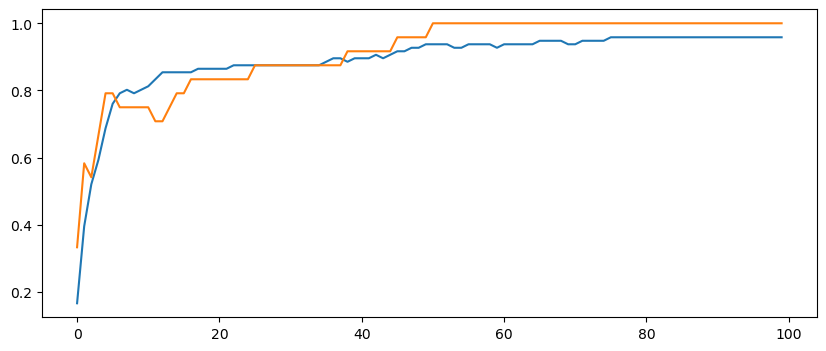

In [20]:
plt.figure(figsize = (10,4))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")

